# Analiza i porównanie najlepszych konfiguracji parametrów

In [1]:
import os
import glob

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Topologia meeting

In [2]:
sns.set_theme(style="whitegrid")

# ============================================================
# LOAD RESULTS
# ============================================================

RESULTS_PATH = "results/best_configs_v1"

files = glob.glob(os.path.join(RESULTS_PATH, "meeting*.csv"))

print("Loaded files:")
for f in files:
    print(os.path.basename(f))

dfs = []

for file in files:
    df_tmp = pd.read_csv(file)

    # source filename
    df_tmp["source_file"] = os.path.basename(file)

    dfs.append(df_tmp)

df_meeting = pd.concat(dfs, ignore_index=True)

print(f"\nTotal rows: {len(df_meeting)}")

display(df_meeting.head())

print("\nColumns:")
print(df_meeting.columns.tolist())

Loaded files:
meeting_n500_array_20315406.csv
meeting_n100_array_20353632.csv
meeting_n200_array_20353632.csv
meeting_n300_array_20315406.csv
meeting_n50_array_20353632.csv

Total rows: 75


,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,z_star,n_steps,r0,r1,gamma,build_target_ratio,seed,average,best,source_file
0,2,meeting,500,5,5,10,1000,0.0005,1.0,0.005,0.8,123,63.818691,47.183104,meeting_n500_array_20315406.csv
1,1,meeting,500,5,5,10,1000,0.0005,1.0,0.005,0.8,123,62.138087,49.713811,meeting_n500_array_20315406.csv
2,0,meeting,500,5,5,10,1000,0.0005,1.0,0.005,0.8,123,61.609376,48.553628,meeting_n500_array_20315406.csv
3,3,meeting,500,5,5,10,1000,0.0005,1.0,0.005,0.8,123,61.446657,47.567721,meeting_n500_array_20315406.csv
4,4,meeting,500,5,5,10,1000,0.0005,1.0,0.005,0.8,123,62.282137,50.902658,meeting_n500_array_20315406.csv



Columns:
['array_task_id', 'topology', 'number_of_islands', 'number_of_migrants', 'migration_interval', 'z_star', 'n_steps', 'r0', 'r1', 'gamma', 'build_target_ratio', 'seed', 'average', 'best', 'source_file']


In [3]:
df_meeting

,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,z_star,n_steps,r0,r1,gamma,build_target_ratio,seed,average,best,source_file
0,2,meeting,500,5,5,10,1000,0.0005,1.0,0.005,0.8,123,63.818691,47.183104,meeting_n500_array_20315406.csv
1,1,meeting,500,5,5,10,1000,0.0005,1.0,0.005,0.8,123,62.138087,49.713811,meeting_n500_array_20315406.csv
2,0,meeting,500,5,5,10,1000,0.0005,1.0,0.005,0.8,123,61.609376,48.553628,meeting_n500_array_20315406.csv
3,3,meeting,500,5,5,10,1000,0.0005,1.0,0.005,0.8,123,61.446657,47.567721,meeting_n500_array_20315406.csv
4,4,meeting,500,5,5,10,1000,0.0005,1.0,0.005,0.8,123,62.282137,50.902658,meeting_n500_array_20315406.csv
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,40,meeting,50,5,5,5,500,0.0010,1.0,0.001,0.8,123,280.278350,234.234796,meeting_n50_array_20353632.csv
71,41,meeting,50,5,5,5,500,0.0010,1.0,0.001,0.8,123,279.712695,236.735301,meeting_n50_array_20353632.csv
72,43,meeting,50,5,5,5,500,0.0010,1.0,0.001,0.8,123,278.672664,238.818174,meeting_n50_array_20353632.csv
73,42,meeting,50,5,5,5,500,0.0010,1.0,0.001,0.8,123,245.895347,226.965400,meeting_n50_array_20353632.csv


In [4]:
# tworzymy nową kolumnę config_id do łatwego grupowania wyników

config_cols = [
    "number_of_islands",
    "number_of_islands",
    "migration_interval",
    "z_star",
    "n_steps",
    "r0",
    "r1",
    "gamma"

]

df_meeting["config_id"] = (
    df_meeting[config_cols]
    .astype(str)
    .agg("_".join, axis=1)
)

In [5]:
meeting_summary = (
    df_meeting
    .groupby(["config_id","topology","number_of_islands"], as_index=False)
    .agg(
        mean_best=("best", "mean"),
        std_best=("best", "std"),
        min_best=("best", "min"),
        max_best=("best", "max"),
        median_best=("best", "median"),
        mean_avg=("average", "mean"),
        std_avg=("average", "std"),
        min_avg=("average", "min"),
        max_avg=("average", "max"),
        median_avg=("average", "median"),
    )
)

meeting_summary

,config_id,topology,number_of_islands,mean_best,std_best,min_best,max_best,median_best,mean_avg,std_avg,min_avg,max_avg,median_avg
0,100_100_5_10_500_0.0005_1.0_0.001,meeting,100,161.934634,9.688102,152.816982,175.738106,158.388080,202.206421,9.067233,194.970053,215.748396,196.517710
1,100_100_5_10_500_0.001_1.0_0.001,meeting,100,159.686322,14.112712,145.992760,178.323809,153.137396,203.062983,19.205389,185.255702,226.908799,194.114270
2,100_100_5_10_500_0.001_2.0_0.001,meeting,100,155.460940,10.934231,145.672172,171.674625,152.742230,194.164416,16.833833,176.885986,215.552298,191.792073
3,200_200_5_10_500_0.001_2.0_0.001,meeting,200,111.927751,3.674862,105.709522,115.053862,113.589917,135.956438,4.904240,133.287894,144.715462,133.925410
4,200_200_5_5_500_0.0005_2.0_0.001,meeting,200,121.554747,7.556155,109.326765,128.911084,121.503731,147.253108,6.892753,137.141807,154.770394,145.927045
5,200_200_5_5_500_0.001_2.0_0.001,meeting,200,117.764720,6.852201,107.222019,124.685609,119.187385,147.827986,9.613278,138.562651,161.436442,144.972258
6,300_300_5_10_1000_0.00025_2.0_0.005,meeting,300,88.673335,7.465663,77.825988,97.149535,89.918102,115.701104,11.874377,98.002157,125.707431,121.789988
7,300_300_5_10_1000_0.001_2.0_0.005,meeting,300,80.891533,5.400148,75.975925,88.879210,80.128208,105.646160,6.156441,99.245399,113.058927,104.486511
8,300_300_5_10_500_0.001_1.0_0.001,meeting,300,88.245977,5.914922,79.930516,94.654200,89.268795,111.343845,11.326437,95.550640,121.241029,117.113138
9,500_500_5_10_1000_0.0005_1.0_0.005,meeting,500,48.784184,1.536924,47.183104,50.902658,48.553628,62.258990,0.939375,61.446657,63.818691,62.138087


In [6]:
meeting_summary.sort_values("mean_best")

,config_id,topology,number_of_islands,mean_best,std_best,min_best,max_best,median_best,mean_avg,std_avg,min_avg,max_avg,median_avg
9,500_500_5_10_1000_0.0005_1.0_0.005,meeting,500,48.784184,1.536924,47.183104,50.902658,48.553628,62.258990,0.939375,61.446657,63.818691,62.138087
10,500_500_5_10_1000_0.001_1.0_0.005,meeting,500,51.875437,6.818036,41.710437,59.755573,54.222845,68.962387,7.343636,58.553682,74.443058,73.703726
11,500_500_5_10_500_0.001_1.0_0.001,meeting,500,53.781570,3.517976,50.116776,57.113170,54.447959,63.589115,3.069008,60.220258,65.926875,65.632274
7,300_300_5_10_1000_0.001_2.0_0.005,meeting,300,80.891533,5.400148,75.975925,88.879210,80.128208,105.646160,6.156441,99.245399,113.058927,104.486511
8,300_300_5_10_500_0.001_1.0_0.001,meeting,300,88.245977,5.914922,79.930516,94.654200,89.268795,111.343845,11.326437,95.550640,121.241029,117.113138
6,300_300_5_10_1000_0.00025_2.0_0.005,meeting,300,88.673335,7.465663,77.825988,97.149535,89.918102,115.701104,11.874377,98.002157,125.707431,121.789988
3,200_200_5_10_500_0.001_2.0_0.001,meeting,200,111.927751,3.674862,105.709522,115.053862,113.589917,135.956438,4.904240,133.287894,144.715462,133.925410
5,200_200_5_5_500_0.001_2.0_0.001,meeting,200,117.764720,6.852201,107.222019,124.685609,119.187385,147.827986,9.613278,138.562651,161.436442,144.972258
4,200_200_5_5_500_0.0005_2.0_0.001,meeting,200,121.554747,7.556155,109.326765,128.911084,121.503731,147.253108,6.892753,137.141807,154.770394,145.927045
2,100_100_5_10_500_0.001_2.0_0.001,meeting,100,155.460940,10.934231,145.672172,171.674625,152.742230,194.164416,16.833833,176.885986,215.552298,191.792073


In [7]:
meeting_summary.sort_values("median_best")

,config_id,topology,number_of_islands,mean_best,std_best,min_best,max_best,median_best,mean_avg,std_avg,min_avg,max_avg,median_avg
9,500_500_5_10_1000_0.0005_1.0_0.005,meeting,500,48.784184,1.536924,47.183104,50.902658,48.553628,62.258990,0.939375,61.446657,63.818691,62.138087
10,500_500_5_10_1000_0.001_1.0_0.005,meeting,500,51.875437,6.818036,41.710437,59.755573,54.222845,68.962387,7.343636,58.553682,74.443058,73.703726
11,500_500_5_10_500_0.001_1.0_0.001,meeting,500,53.781570,3.517976,50.116776,57.113170,54.447959,63.589115,3.069008,60.220258,65.926875,65.632274
7,300_300_5_10_1000_0.001_2.0_0.005,meeting,300,80.891533,5.400148,75.975925,88.879210,80.128208,105.646160,6.156441,99.245399,113.058927,104.486511
8,300_300_5_10_500_0.001_1.0_0.001,meeting,300,88.245977,5.914922,79.930516,94.654200,89.268795,111.343845,11.326437,95.550640,121.241029,117.113138
6,300_300_5_10_1000_0.00025_2.0_0.005,meeting,300,88.673335,7.465663,77.825988,97.149535,89.918102,115.701104,11.874377,98.002157,125.707431,121.789988
3,200_200_5_10_500_0.001_2.0_0.001,meeting,200,111.927751,3.674862,105.709522,115.053862,113.589917,135.956438,4.904240,133.287894,144.715462,133.925410
5,200_200_5_5_500_0.001_2.0_0.001,meeting,200,117.764720,6.852201,107.222019,124.685609,119.187385,147.827986,9.613278,138.562651,161.436442,144.972258
4,200_200_5_5_500_0.0005_2.0_0.001,meeting,200,121.554747,7.556155,109.326765,128.911084,121.503731,147.253108,6.892753,137.141807,154.770394,145.927045
2,100_100_5_10_500_0.001_2.0_0.001,meeting,100,155.460940,10.934231,145.672172,171.674625,152.742230,194.164416,16.833833,176.885986,215.552298,191.792073


<Axes: xlabel='number_of_islands', ylabel='best'>

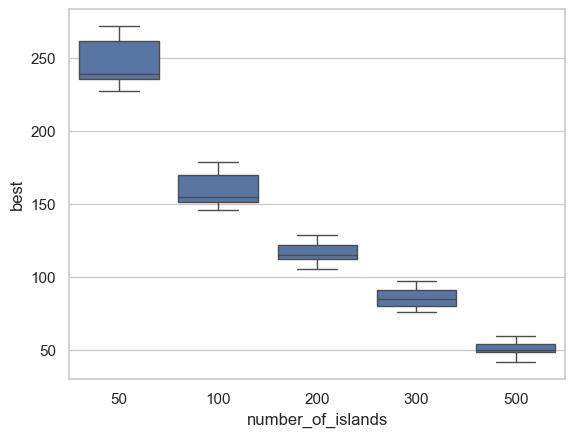

In [8]:
sns.boxplot(
    data=df_meeting,
    x="number_of_islands",
    y="best"
)

## Analiza statystyczna dla 500 wysp

In [9]:
top3_runs = (
    df_meeting[(df_meeting["number_of_islands"] == 500)]
)

top3_runs

,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,z_star,n_steps,r0,r1,gamma,build_target_ratio,seed,average,best,source_file,config_id
0,2,meeting,500,5,5,10,1000,0.0005,1.0,0.005,0.8,123,63.818691,47.183104,meeting_n500_array_20315406.csv,500_500_5_10_1000_0.0005_1.0_0.005
1,1,meeting,500,5,5,10,1000,0.0005,1.0,0.005,0.8,123,62.138087,49.713811,meeting_n500_array_20315406.csv,500_500_5_10_1000_0.0005_1.0_0.005
2,0,meeting,500,5,5,10,1000,0.0005,1.0,0.005,0.8,123,61.609376,48.553628,meeting_n500_array_20315406.csv,500_500_5_10_1000_0.0005_1.0_0.005
3,3,meeting,500,5,5,10,1000,0.0005,1.0,0.005,0.8,123,61.446657,47.567721,meeting_n500_array_20315406.csv,500_500_5_10_1000_0.0005_1.0_0.005
4,4,meeting,500,5,5,10,1000,0.0005,1.0,0.005,0.8,123,62.282137,50.902658,meeting_n500_array_20315406.csv,500_500_5_10_1000_0.0005_1.0_0.005
5,6,meeting,500,5,5,10,1000,0.0010,1.0,0.005,0.8,123,73.703726,54.222845,meeting_n500_array_20315406.csv,500_500_5_10_1000_0.001_1.0_0.005
6,7,meeting,500,5,5,10,1000,0.0010,1.0,0.005,0.8,123,74.443058,54.583364,meeting_n500_array_20315406.csv,500_500_5_10_1000_0.001_1.0_0.005
7,5,meeting,500,5,5,10,1000,0.0010,1.0,0.005,0.8,123,63.819355,49.104965,meeting_n500_array_20315406.csv,500_500_5_10_1000_0.001_1.0_0.005
8,10,meeting,500,5,5,10,500,0.0010,1.0,0.001,0.8,123,65.926875,57.113170,meeting_n500_array_20315406.csv,500_500_5_10_500_0.001_1.0_0.001
9,11,meeting,500,5,5,10,500,0.0010,1.0,0.001,0.8,123,65.926875,57.113170,meeting_n500_array_20315406.csv,500_500_5_10_500_0.001_1.0_0.001


In [10]:
from scipy.stats import kruskal

groups = [
    group["best"].values
    for _, group in top3_runs.groupby("config_id")
]

stat, p = kruskal(*groups)

print(stat, p)

4.355555555555559 0.11329301336363003


## Scale-free topology

In [11]:
RESULTS_PATH = "results/best_configs_v1"

files = glob.glob(os.path.join(RESULTS_PATH, "scale_free*.csv"))

print("Loaded files:")
for f in files:
    print(os.path.basename(f))

dfs = []

for file in files:
    df_tmp = pd.read_csv(file)

    # source filename
    df_tmp["source_file"] = os.path.basename(file)

    dfs.append(df_tmp)

df_scale_free = pd.concat(dfs, ignore_index=True)

print(f"\nTotal rows: {len(df_scale_free)}")

display(df_scale_free.head())

Loaded files:
scale_free_n200_array_20313659.csv
scale_free_n300_array_20313659.csv
scale_free_n50_array_20313659.csv
scale_free_n500_array_20313659.csv
scale_free_n100_array_20313659.csv

Total rows: 75


,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,m0,m,seed,average,best,source_file
0,30,scale_free,200,5,5,15,14,123,147.098527,80.315462,scale_free_n200_array_20313659.csv
1,31,scale_free,200,5,5,15,14,123,152.691503,80.705968,scale_free_n200_array_20313659.csv
2,32,scale_free,200,5,5,15,14,123,153.905586,79.036419,scale_free_n200_array_20313659.csv
3,33,scale_free,200,5,5,15,14,123,154.768352,90.291510,scale_free_n200_array_20313659.csv
4,34,scale_free,200,5,5,15,14,123,139.132327,71.164097,scale_free_n200_array_20313659.csv


In [12]:
config_cols = [
    "number_of_islands",
    "number_of_islands",
    "migration_interval",
    "m0",
    "m"
]

df_scale_free["config_id"] = (
    df_scale_free[config_cols]
    .astype(str)
    .agg("_".join, axis=1)
)

In [13]:
df_scale_free

,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,m0,m,seed,average,best,source_file,config_id
0,30,scale_free,200,5,5,15,14,123,147.098527,80.315462,scale_free_n200_array_20313659.csv,200_200_5_15_14
1,31,scale_free,200,5,5,15,14,123,152.691503,80.705968,scale_free_n200_array_20313659.csv,200_200_5_15_14
2,32,scale_free,200,5,5,15,14,123,153.905586,79.036419,scale_free_n200_array_20313659.csv,200_200_5_15_14
3,33,scale_free,200,5,5,15,14,123,154.768352,90.291510,scale_free_n200_array_20313659.csv,200_200_5_15_14
4,34,scale_free,200,5,5,15,14,123,139.132327,71.164097,scale_free_n200_array_20313659.csv,200_200_5_15_14
...,...,...,...,...,...,...,...,...,...,...,...,...
70,55,scale_free,100,5,5,20,13,123,179.184287,127.277825,scale_free_n100_array_20313659.csv,100_100_5_20_13
71,56,scale_free,100,5,5,20,13,123,212.740723,145.044397,scale_free_n100_array_20313659.csv,100_100_5_20_13
72,59,scale_free,100,5,5,20,13,123,212.892030,139.555531,scale_free_n100_array_20313659.csv,100_100_5_20_13
73,57,scale_free,100,5,5,20,13,123,210.908170,135.158048,scale_free_n100_array_20313659.csv,100_100_5_20_13


In [14]:
scale_free_summary = (
    df_scale_free
    .groupby(["config_id","topology","number_of_islands"], as_index=False)
    .agg(
        mean_best=("best", "mean"),
        std_best=("best", "std"),
        min_best=("best", "min"),
        max_best=("best", "max"),
        median_best=("best", "median"),
        mean_avg=("average", "mean"),
        std_avg=("average", "std"),
        min_avg=("average", "min"),
        max_avg=("average", "max"),
        median_avg=("average", "median"),
    )
)

scale_free_summary

,config_id,topology,number_of_islands,mean_best,std_best,min_best,max_best,median_best,mean_avg,std_avg,min_avg,max_avg,median_avg
0,100_100_5_20_13,scale_free,100,139.742250,9.312970,127.277825,151.675449,139.555531,206.053124,15.075100,179.184287,214.540411,212.740723
1,100_100_5_20_15,scale_free,100,145.285548,7.080622,136.608439,154.127461,147.368166,200.646857,8.447857,189.248335,211.984340,202.108526
2,100_100_5_20_16,scale_free,100,136.432096,11.942419,126.880463,154.129889,129.483435,188.261924,11.339419,176.294838,206.108014,183.758137
3,200_200_5_12_11,scale_free,200,76.414904,5.610225,69.568359,81.772324,79.256173,148.318257,9.558900,134.974849,158.129228,151.375686
4,200_200_5_15_14,scale_free,200,80.302691,6.801776,71.164097,90.291510,80.315462,149.519259,6.530779,139.132327,154.768352,152.691503
5,200_200_5_15_15,scale_free,200,76.476043,4.023665,70.087553,80.999886,77.588128,142.482966,10.075900,129.653547,154.245161,146.951756
6,300_300_5_15_15,scale_free,300,45.463471,4.411655,39.963290,50.262052,45.787259,124.410201,4.248353,118.295679,129.625247,124.019410
7,300_300_5_8_7,scale_free,300,58.583119,7.136624,53.168214,67.371334,53.869526,188.552153,4.211220,181.929196,192.373979,188.204463
8,300_300_5_8_8,scale_free,300,53.409776,6.992164,47.076793,61.106656,50.594551,168.781515,9.872770,159.512365,182.699583,165.761974
9,500_500_5_15_14,scale_free,500,24.137909,2.955835,20.701186,28.784801,23.315194,99.441686,7.250177,93.906362,110.604909,94.846973


<Axes: xlabel='number_of_islands', ylabel='best'>

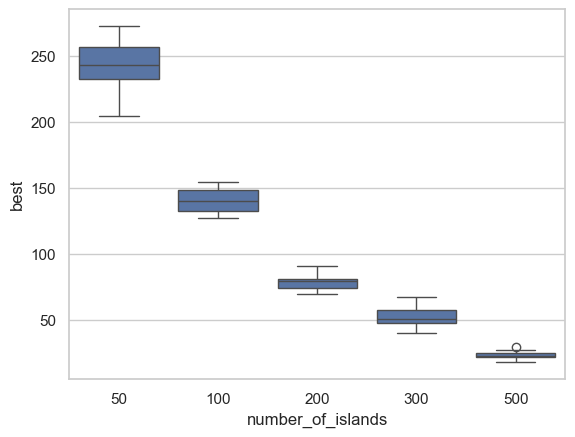

In [15]:
sns.boxplot(
    data=df_scale_free,
    x="number_of_islands",
    y="best"
)

## Analiza statystyczna

In [16]:
top3_runs = (
    df_scale_free[(df_scale_free["number_of_islands"] == 500)]
)

groups = [
    group["best"].values
    for _, group in top3_runs.groupby("config_id")
]

stat, p = kruskal(*groups)

print(stat, p)

2.2239713774597556 0.3289052088493752


In [17]:
top3_runs

,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,m0,m,seed,average,best,source_file,config_id
45,3,scale_free,500,5,5,20,19,123,85.411672,22.544211,scale_free_n500_array_20313659.csv,500_500_5_20_19
46,1,scale_free,500,5,5,20,19,123,85.325762,22.600780,scale_free_n500_array_20313659.csv,500_500_5_20_19
47,2,scale_free,500,5,5,20,19,123,82.510049,18.281932,scale_free_n500_array_20313659.csv,500_500_5_20_19
48,0,scale_free,500,5,5,20,19,123,82.498808,18.253427,scale_free_n500_array_20313659.csv,500_500_5_20_19
49,4,scale_free,500,5,5,20,19,123,83.018504,23.914107,scale_free_n500_array_20313659.csv,500_500_5_20_19
50,5,scale_free,500,5,5,20,18,123,81.860048,22.671722,scale_free_n500_array_20313659.csv,500_500_5_20_18
51,6,scale_free,500,5,5,20,18,123,100.608175,26.660705,scale_free_n500_array_20313659.csv,500_500_5_20_18
52,7,scale_free,500,5,5,20,18,123,100.413950,25.026140,scale_free_n500_array_20313659.csv,500_500_5_20_18
53,8,scale_free,500,5,5,20,18,123,98.609856,21.996914,scale_free_n500_array_20313659.csv,500_500_5_20_18
54,9,scale_free,500,5,5,20,18,123,78.946079,17.599991,scale_free_n500_array_20313659.csv,500_500_5_20_18


## Complete topology

In [18]:
RESULTS_PATH = "results/best_configs_v1"

files = glob.glob(os.path.join(RESULTS_PATH, "complete*.csv"))

print("Loaded files:")
for f in files:
    print(os.path.basename(f))

dfs = []

for file in files:
    df_tmp = pd.read_csv(file)

    # source filename
    df_tmp["source_file"] = os.path.basename(file)

    dfs.append(df_tmp)

df_complete = pd.concat(dfs, ignore_index=True)

print(f"\nTotal rows: {len(df_complete)}")

display(df_complete.head())

Loaded files:
complete_n500_array_20315054.csv
complete_n100_array_20315054.csv
complete_n200_array_20315054.csv
complete_n300_array_20315054.csv
complete_n50_array_20315054.csv

Total rows: 25


,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,average,best,source_file
0,20,complete,500,5,5,52.482854,42.093114,complete_n500_array_20315054.csv
1,21,complete,500,5,5,52.482854,42.093114,complete_n500_array_20315054.csv
2,22,complete,500,5,5,94.491498,52.269432,complete_n500_array_20315054.csv
3,23,complete,500,5,5,57.367060,42.470960,complete_n500_array_20315054.csv
4,24,complete,500,5,5,69.486343,49.055172,complete_n500_array_20315054.csv


In [19]:
complete_summary = (
    df_complete
    .groupby(["topology","number_of_islands"], as_index=False)
    .agg(
        mean_best=("best", "mean"),
        std_best=("best", "std"),
        min_best=("best", "min"),
        max_best=("best", "max"),
        median_best=("best", "median"),
        mean_avg=("average", "mean"),
        std_avg=("average", "std"),
        min_avg=("average", "min"),
        max_avg=("average", "max"),
        median_avg=("average", "median"),
    )
)

complete_summary

,topology,number_of_islands,mean_best,std_best,min_best,max_best,median_best,mean_avg,std_avg,min_avg,max_avg,median_avg
0,complete,50,238.240552,2.273440,235.777742,240.158113,239.331050,269.214739,2.023646,265.703022,270.727155,269.886729
1,complete,100,143.733269,7.957138,137.144861,152.621582,139.622431,195.639476,5.798808,188.735106,202.246417,195.439627
2,complete,200,99.548170,2.318905,95.921994,101.343986,100.542587,145.865687,4.230812,139.420650,150.167057,147.732975
3,complete,300,75.328563,9.453703,65.645665,87.388268,70.234101,102.361683,21.582584,82.305031,137.123448,101.678400
4,complete,500,45.596358,4.764631,42.093114,52.269432,42.470960,65.262122,17.756350,52.482854,94.491498,57.367060


# Porównanie 3 najlepszych konfiguracji meeting i scale-free z complete

In [20]:
comparison = pd.concat(
    [complete_summary, scale_free_summary, meeting_summary],
    ignore_index=True
)


In [21]:
comparison

,topology,number_of_islands,mean_best,std_best,min_best,max_best,median_best,mean_avg,std_avg,min_avg,max_avg,median_avg,config_id
0,complete,50,238.240552,2.273440,235.777742,240.158113,239.331050,269.214739,2.023646,265.703022,270.727155,269.886729,NaN
1,complete,100,143.733269,7.957138,137.144861,152.621582,139.622431,195.639476,5.798808,188.735106,202.246417,195.439627,NaN
2,complete,200,99.548170,2.318905,95.921994,101.343986,100.542587,145.865687,4.230812,139.420650,150.167057,147.732975,NaN
3,complete,300,75.328563,9.453703,65.645665,87.388268,70.234101,102.361683,21.582584,82.305031,137.123448,101.678400,NaN
4,complete,500,45.596358,4.764631,42.093114,52.269432,42.470960,65.262122,17.756350,52.482854,94.491498,57.367060,NaN
5,scale_free,100,139.742250,9.312970,127.277825,151.675449,139.555531,206.053124,15.075100,179.184287,214.540411,212.740723,100_100_5_20_13
6,scale_free,100,145.285548,7.080622,136.608439,154.127461,147.368166,200.646857,8.447857,189.248335,211.984340,202.108526,100_100_5_20_15
7,scale_free,100,136.432096,11.942419,126.880463,154.129889,129.483435,188.261924,11.339419,176.294838,206.108014,183.758137,100_100_5_20_16
8,scale_free,200,76.414904,5.610225,69.568359,81.772324,79.256173,148.318257,9.558900,134.974849,158.129228,151.375686,200_200_5_12_11
9,scale_free,200,80.302691,6.801776,71.164097,90.291510,80.315462,149.519259,6.530779,139.132327,154.768352,152.691503,200_200_5_15_14


<Axes: xlabel='topology', ylabel='mean_best'>

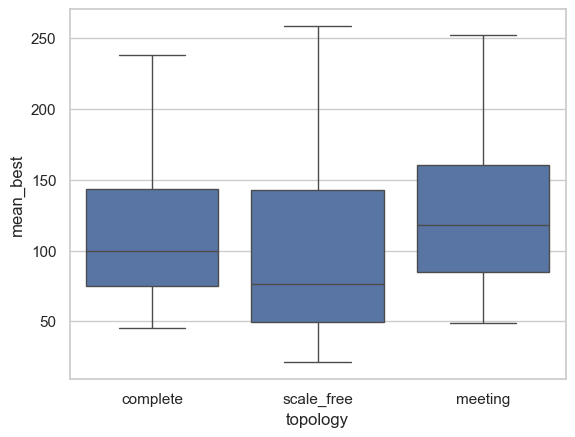

In [22]:
sns.boxplot(
    data=comparison,
    x="topology",
    y="mean_best"
)

In [40]:
# Tylko dla 500 wysp
comparison[comparison["number_of_islands"]==500]


,topology,number_of_islands,mean_best,std_best,min_best,max_best,median_best,mean_avg,std_avg,min_avg,max_avg,median_avg,config_id
4,complete,500,45.596358,4.764631,42.093114,52.269432,42.470960,65.262122,17.756350,52.482854,94.491498,57.367060,NaN
14,scale_free,500,24.137909,2.955835,20.701186,28.784801,23.315194,99.441686,7.250177,93.906362,110.604909,94.846973,500_500_5_15_14
15,scale_free,500,22.791094,3.448255,17.599991,26.660705,22.671722,92.087622,10.744423,78.946079,100.608175,98.609856,500_500_5_20_18
16,scale_free,500,21.118891,2.659887,18.253427,23.914107,22.544211,83.752959,1.490149,82.498808,85.411672,83.018504,500_500_5_20_19
29,meeting,500,48.784184,1.536924,47.183104,50.902658,48.553628,62.258990,0.939375,61.446657,63.818691,62.138087,500_500_5_10_1000_0.0005_1.0_0.005
30,meeting,500,51.875437,6.818036,41.710437,59.755573,54.222845,68.962387,7.343636,58.553682,74.443058,73.703726,500_500_5_10_1000_0.001_1.0_0.005
31,meeting,500,53.781570,3.517976,50.116776,57.113170,54.447959,63.589115,3.069008,60.220258,65.926875,65.632274,500_500_5_10_500_0.001_1.0_0.001


# Porównanie 3 najlepszych konfiguracji dla różnej liczby wysp

In [41]:
df_compare = pd.concat([df_complete, df_meeting, df_scale_free])
df_compare

,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,average,best,source_file,z_star,n_steps,r0,r1,gamma,build_target_ratio,seed,config_id,m0,m
0,20,complete,500,5,5,52.482854,42.093114,complete_n500_array_20315054.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,21,complete,500,5,5,52.482854,42.093114,complete_n500_array_20315054.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,22,complete,500,5,5,94.491498,52.269432,complete_n500_array_20315054.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,23,complete,500,5,5,57.367060,42.470960,complete_n500_array_20315054.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,24,complete,500,5,5,69.486343,49.055172,complete_n500_array_20315054.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,55,scale_free,100,5,5,179.184287,127.277825,scale_free_n100_array_20313659.csv,NaN,NaN,NaN,NaN,NaN,NaN,123.0,100_100_5_20_13,20.0,13.0
71,56,scale_free,100,5,5,212.740723,145.044397,scale_free_n100_array_20313659.csv,NaN,NaN,NaN,NaN,NaN,NaN,123.0,100_100_5_20_13,20.0,13.0
72,59,scale_free,100,5,5,212.892030,139.555531,scale_free_n100_array_20313659.csv,NaN,NaN,NaN,NaN,NaN,NaN,123.0,100_100_5_20_13,20.0,13.0
73,57,scale_free,100,5,5,210.908170,135.158048,scale_free_n100_array_20313659.csv,NaN,NaN,NaN,NaN,NaN,NaN,123.0,100_100_5_20_13,20.0,13.0


In [42]:
df_islands_compare = (
    df_compare.groupby(
        ["topology", "number_of_islands"],
        as_index=False
    )
    .agg(
        mean_best=("best", "mean"),
        std_best=("best", "std"),
        min_best=("best", "min"),
        max_best=("best", "max"),
        median_best=("best", "median"),
        mean_avg=("average", "mean"),
        std_avg=("average", "std"),
        min_avg=("average", "min"),
        max_avg=("average", "max"),
        median_avg=("average", "median"),
    )
)

display(df_islands_compare)

,topology,number_of_islands,mean_best,std_best,min_best,max_best,median_best,mean_avg,std_avg,min_avg,max_avg,median_avg
0,complete,50,238.240552,2.273440,235.777742,240.158113,239.331050,269.214739,2.023646,265.703022,270.727155,269.886729
1,complete,100,143.733269,7.957138,137.144861,152.621582,139.622431,195.639476,5.798808,188.735106,202.246417,195.439627
2,complete,200,99.548170,2.318905,95.921994,101.343986,100.542587,145.865687,4.230812,139.420650,150.167057,147.732975
3,complete,300,75.328563,9.453703,65.645665,87.388268,70.234101,102.361683,21.582584,82.305031,137.123448,101.678400
4,complete,500,45.596358,4.764631,42.093114,52.269432,42.470960,65.262122,17.756350,52.482854,94.491498,57.367060
5,meeting,50,246.536630,15.817957,226.965400,271.501903,238.818174,273.968657,17.985276,245.895347,301.599155,278.672664
6,meeting,100,159.027299,11.207047,145.672172,178.323809,154.711324,199.811273,15.068286,176.885986,226.908799,196.395382
7,meeting,200,117.082406,7.098291,105.709522,128.911084,115.377082,143.679177,8.880308,133.287894,161.436442,144.715462
8,meeting,300,85.936948,6.922605,75.975925,97.149535,85.283691,110.897036,10.292213,95.550640,125.707431,110.932109
9,meeting,500,51.480397,4.694227,41.710437,59.755573,50.116776,64.936831,5.229602,58.553682,74.443058,63.818691


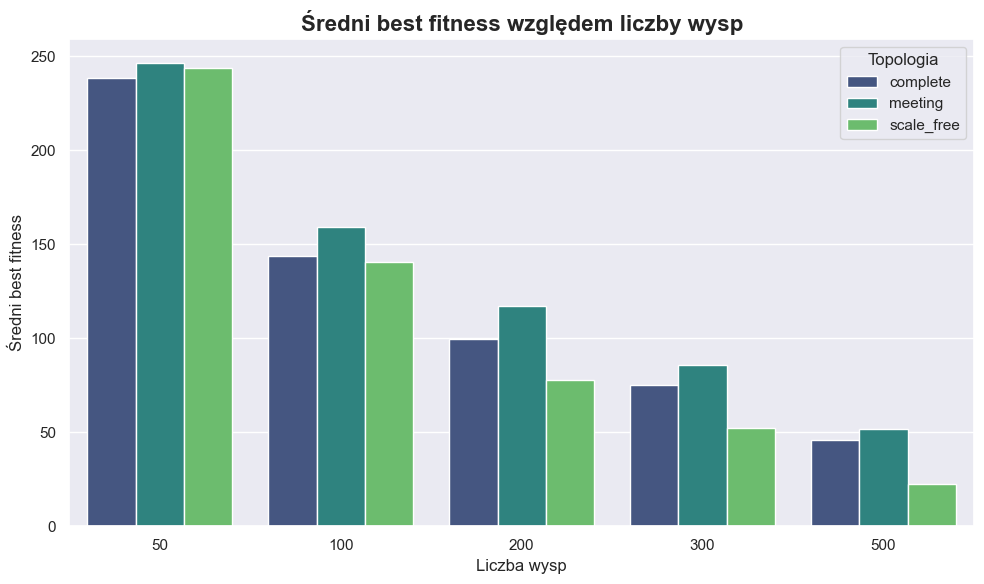

In [43]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_islands_compare,
    x="number_of_islands",
    y="mean_best",
    hue="topology",
    palette="viridis",
)

plt.title(
    "Średni best fitness względem liczby wysp",
    fontsize=16,
    fontweight="bold",
)

plt.xlabel("Liczba wysp")
plt.ylabel("Średni best fitness")

plt.legend(title="Topologia")

plt.tight_layout()
plt.show()

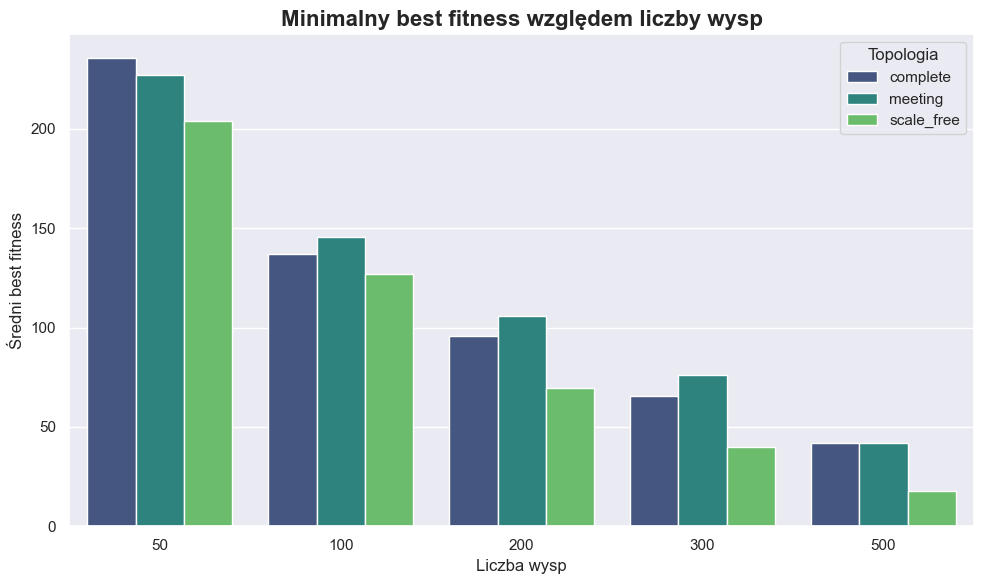

In [44]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_islands_compare,
    x="number_of_islands",
    y="min_best",
    hue="topology",
    palette="viridis",
)

plt.title(
    "Minimalny best fitness względem liczby wysp",
    fontsize=16,
    fontweight="bold",
)

plt.xlabel("Liczba wysp")
plt.ylabel("Średni best fitness")

plt.legend(title="Topologia")

plt.tight_layout()
plt.show()

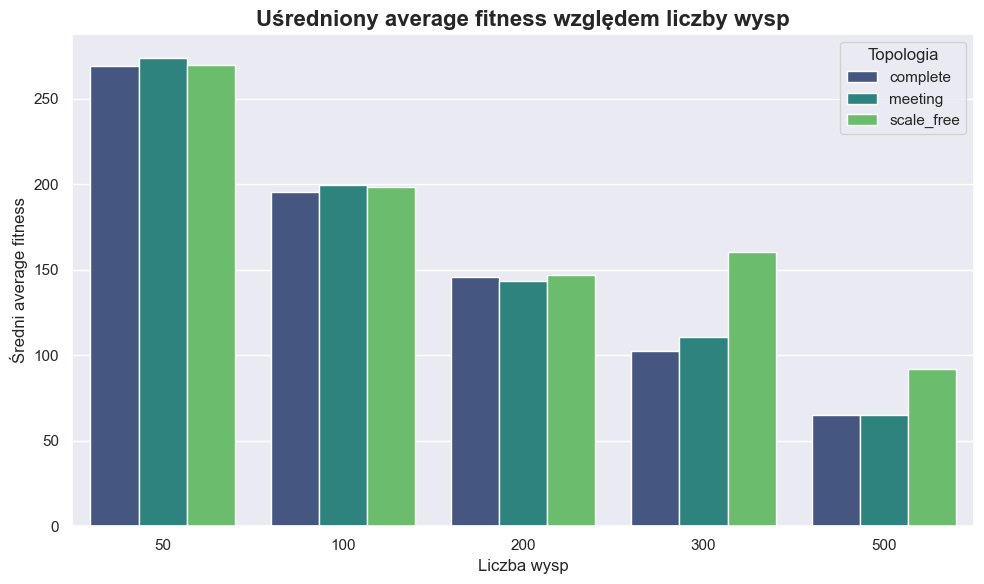

In [45]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_islands_compare,
    x="number_of_islands",
    y="mean_avg",
    hue="topology",
    palette="viridis",
)

plt.title(
    "Uśredniony average fitness względem liczby wysp",
    fontsize=16,
    fontweight="bold",
)

plt.xlabel("Liczba wysp")
plt.ylabel("Średni average fitness")

plt.legend(title="Topologia")

plt.tight_layout()
plt.show()

# Analiza statystyczna różnych topologii

In [46]:
# bierzemy wartosci dla wszystkich top5 konfiguracji
meeting_values = df_meeting[(df_meeting["number_of_islands"] == 500)]["best"]
scale_free_values = df_scale_free[(df_scale_free["number_of_islands"] == 500)]["best"]
complete_values = df_complete[(df_complete["number_of_islands"] == 500)]["best"]
stat, p = kruskal(
    meeting_values,
    scale_free_values,
    complete_values,
)

print(stat, p)

26.188639760837084 2.0568808350135265e-06


In [47]:
import scikit_posthocs as sp

df_compare = pd.concat([
    df_meeting[(df_meeting["number_of_islands"] == 500)],
    df_scale_free[(df_scale_free["number_of_islands"] == 500)],
    df_complete[(df_complete["number_of_islands"] == 500)],
], ignore_index=True)

posthoc = sp.posthoc_dunn(
    df_compare,
    val_col="best",
    group_col="topology",
    p_adjust="holm"
)

print(posthoc)

            complete   meeting  scale_free
complete    1.000000  0.278453    0.025173
meeting     0.278453  1.000000    0.000001
scale_free  0.025173  0.000001    1.000000


In [48]:
df_compare.groupby("topology")["best"].agg(
    ["mean","median","std"]
)

,mean,median,std
topology,,,
complete,45.596358,42.470960,4.764631
meeting,51.480397,50.116776,4.694227
scale_free,22.682632,22.671722,3.090123


In [49]:
# bierzemy top1 konfigurację
best_config_id_meeting = (
    meeting_summary
    .sort_values("mean_best")
    .iloc[0]["config_id"]
)

top1_meeting = df_meeting[
    df_meeting["config_id"] == best_config_id_meeting
]

In [50]:
best_config_id_scale = (
    scale_free_summary
    .sort_values("mean_best")
    .iloc[0]["config_id"]
)

top1_scale_free = df_scale_free[
    df_scale_free["config_id"] == best_config_id_scale
]

top1_scale_free

,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,m0,m,seed,average,best,source_file,config_id
45,3,scale_free,500,5,5,20,19,123,85.411672,22.544211,scale_free_n500_array_20313659.csv,500_500_5_20_19
46,1,scale_free,500,5,5,20,19,123,85.325762,22.600780,scale_free_n500_array_20313659.csv,500_500_5_20_19
47,2,scale_free,500,5,5,20,19,123,82.510049,18.281932,scale_free_n500_array_20313659.csv,500_500_5_20_19
48,0,scale_free,500,5,5,20,19,123,82.498808,18.253427,scale_free_n500_array_20313659.csv,500_500_5_20_19
49,4,scale_free,500,5,5,20,19,123,83.018504,23.914107,scale_free_n500_array_20313659.csv,500_500_5_20_19


In [51]:
df_compare = pd.concat([
    top1_meeting,
    top1_scale_free,
    df_complete[df_complete['number_of_islands']==500]
], ignore_index=True)

df_compare.groupby("topology")["best"].agg(
    ["mean","median","std"]
)

,mean,median,std
topology,,,
complete,45.596358,42.470960,4.764631
meeting,48.784184,48.553628,1.536924
scale_free,21.118891,22.544211,2.659887


In [52]:
stat, p = kruskal(
    top1_meeting['best'],
    top1_scale_free['best'],
    complete_values,
)

print(stat, p)

9.797495527728087 0.007455913792249077


In [53]:
df_compare = pd.concat([
    top1_meeting,
    top1_scale_free,
    df_complete[(df_complete["number_of_islands"] == 500)]
], ignore_index=True)

posthoc = sp.posthoc_dunn(
    df_compare,
    val_col="best",
    group_col="topology",
    p_adjust="holm"
)

print(posthoc)

            complete   meeting  scale_free
complete    1.000000  0.524148    0.039031
meeting     0.524148  1.000000    0.008861
scale_free  0.039031  0.008861    1.000000


In [54]:
def analyze_island_count(df, island_count):

    subset = df[df["number_of_islands"] == island_count]

    groups = [
        group["best"].values
        for _, group in subset.groupby("topology")
    ]

    H, p = kruskal(*groups)

    dunn = sp.posthoc_dunn(
        subset,
        val_col="best",
        group_col="topology",
        p_adjust="holm"
    )

    return H, p, dunn

In [55]:
df_all = pd.concat([
    df_complete,
    df_meeting,
    df_scale_free
], ignore_index=True)

for n in sorted(df_all["number_of_islands"].unique()):

    H, p, dunn = analyze_island_count(df_all, n)

    print(f"\n=== {n} islands ===")
    print(f"Kruskal H={H:.3f}, p={p:.5f}")
    print(dunn)


=== 50 islands ===
Kruskal H=0.645, p=0.72418
            complete  meeting  scale_free
complete         1.0      1.0         1.0
meeting          1.0      1.0         1.0
scale_free       1.0      1.0         1.0

=== 100 islands ===
Kruskal H=15.616, p=0.00041
            complete   meeting  scale_free
complete    1.000000  0.040861    0.705437
meeting     0.040861  1.000000    0.000412
scale_free  0.705437  0.000412    1.000000

=== 200 islands ===
Kruskal H=28.583, p=0.00000
            complete       meeting    scale_free
complete    1.000000  1.174572e-01  1.174572e-01
meeting     0.117457  1.000000e+00  2.692395e-07
scale_free  0.117457  2.692395e-07  1.000000e+00

=== 300 islands ===
Kruskal H=26.165, p=0.00000
            complete   meeting  scale_free
complete    1.000000  0.221643    0.035697
meeting     0.221643  1.000000    0.000001
scale_free  0.035697  0.000001    1.000000

=== 500 islands ===
Kruskal H=26.189, p=0.00000
            complete   meeting  scale_free
comple

In [56]:
results = []

for n in sorted(df_all["number_of_islands"].unique()):

    H, p, _ = analyze_island_count(df_all, n)

    results.append({
        "islands": n,
        "H": H,
        "p": p
    })

results_df = pd.DataFrame(results)

In [57]:
results_df

,islands,H,p
0,50,0.645441,7.241762e-01
1,100,15.616155,4.064386e-04
2,200,28.583438,6.211339e-07
3,300,26.164934,2.081405e-06
4,500,26.188640,2.056881e-06


In [60]:
from cliffs_delta import cliffs_delta

for n in [50, 100, 200, 300, 500]:
    delta, interpretation = cliffs_delta(
        df_complete[df_complete['number_of_islands']==n]['best'],
        df_meeting[df_meeting['number_of_islands']==n]['best'],
    )
    print(n)
    print(delta)
    print(interpretation)

50
-0.14666666666666667
negligible
100
-0.7866666666666666
large
200
-1.0
large
300
-0.6266666666666667
large
500
-0.5733333333333334
large
